In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('last_sheet.csv')

In [3]:
df.sample(5)

,C,Mn,Si,Cr,Mo,Ni,Al,V,Tq,AGS,Ms
61,0.20,1.44,0.00,0.00,0.00,0.49,0.0,0.09,843,12.0,388.0000
10,0.39,0.65,0.24,0.67,0.15,1.60,0.0,0.00,900,6.9,341.0788
25,0.54,0.46,0.00,0.00,0.00,0.00,0.0,0.00,910,8.0,324.0000
73,0.15,0.63,0.00,0.00,0.24,1.90,0.0,0.00,927,8.0,461.7000
58,0.62,0.95,2.01,0.15,0.00,0.00,0.0,0.00,871,6.5,249.0000


In [4]:
X = df[['C', 'Ni', 'Mn']]  
y = df['Ms']     

In [5]:
X.sample(5)

,C,Ni,Mn
65,0.11,3.33,0.45
30,1.13,0.00,0.30
9,0.15,0.00,1.90
22,0.20,0.00,0.81
11,0.39,1.60,0.65


In [6]:
y.sample(5)

70    397.20000
11    330.06686
76    393.00000
68    339.70000
4     366.00000
Name: Ms, dtype: float64

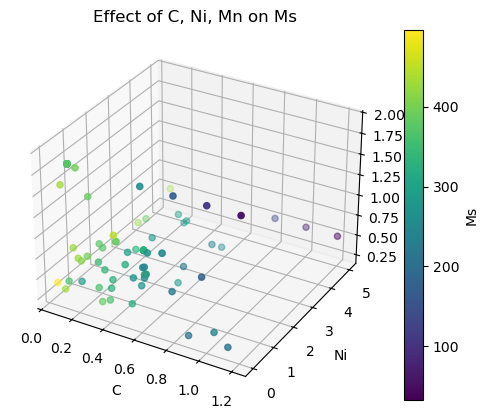

In [7]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

sc = ax.scatter(df['C'], df['Ni'], df['Mn'], c=df['Ms'])

ax.set_xlabel('C')
ax.set_ylabel('Ni')
ax.set_zlabel('Mn')

plt.title("Effect of C, Ni, Mn on Ms")
plt.colorbar(sc, label='Ms')

plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
model = LinearRegression()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.857542549185452
MSE: 1292.0779679774148


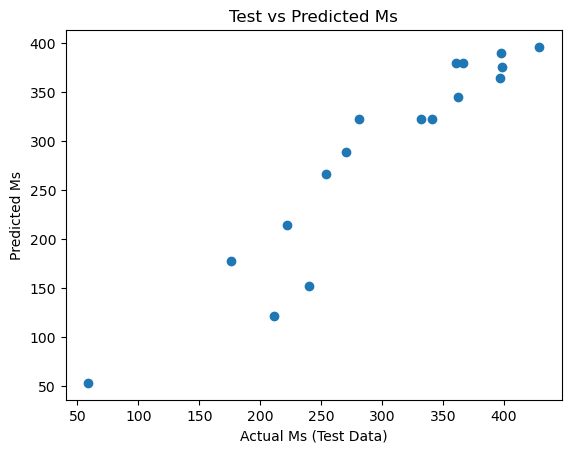

In [13]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ms (Test Data)")
plt.ylabel("Predicted Ms")
plt.title("Test vs Predicted Ms")
plt.show()

In [14]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 482.4306563456873
Coefficients: [-311.23712775  -11.85148119  -29.4614095 ]


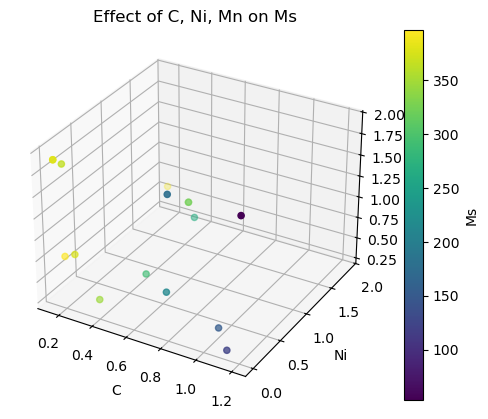

In [16]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

sc = ax.scatter(X_test['C'], X_test['Ni'], X_test['Mn'], c=y_pred.flatten())

ax.set_xlabel('C')
ax.set_ylabel('Ni')
ax.set_zlabel('Mn')

plt.title("Effect of C, Ni, Mn on Ms")
plt.colorbar(sc, label='Ms')

plt.show()

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [18]:
df = pd.read_csv("combined.csv")

X = df[['C', 'Ni', 'Mn']].values
y = df['Ms'].values.reshape(-1, 1)


In [20]:
df.dropna(inplace=True)

In [25]:
X = df[['C', 'Ni', 'Mn']].values
y = df['Ms'].values.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [26]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Add bias
X = np.c_[np.ones((X.shape[0], 1)), X]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [28]:
def gradient_descent(X, y, lr, epochs, batch_size):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for epoch in range(epochs):
        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            predictions = X_batch @ theta
            error = predictions - y_batch

            gradients = (2/len(X_batch)) * X_batch.T @ error
            theta -= lr * gradients

        loss = np.mean((X @ theta - y) ** 2)
        losses.append(loss)

    return theta, losses


In [29]:
learning_rates = [0.001, 0.01, 0.1]
batch_sizes = [8, 16, 32]
epochs_list = [50, 100]

results = []



In [30]:
for lr in learning_rates:
    for batch in batch_sizes:
        for ep in epochs_list:
            
            theta, losses = gradient_descent(X_train, y_train, lr, ep, batch)
            
            y_pred = X_test @ theta
            
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            
            results.append({
                "learning_rate": lr,
                "batch_size": batch,
                "epochs": ep,
                "R2": r2,
                "MSE": mse
            })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

    learning_rate  batch_size  epochs        R2           MSE
0           0.001           8      50 -1.013487  18262.168529
1           0.001           8     100  0.467877   4826.312091
2           0.001          16      50 -3.100335  37189.720430
3           0.001          16     100 -0.661882  15073.143116
4           0.001          32      50 -4.954494  54006.793413
5           0.001          32     100 -2.337451  30270.424546
6           0.010           8      50  0.859220   1276.865343
7           0.010           8     100  0.860389   1266.260532
8           0.010          16      50  0.846921   1388.414928
9           0.010          16     100  0.860629   1264.088594
10          0.010          32      50  0.772843   2060.298565
11          0.010          32     100  0.853044   1332.878245
12          0.100           8      50  0.869246   1185.927269
13          0.100           8     100  0.869246   1185.927269
14          0.100          16      50  0.868281   1194.682152
15      

In [31]:
best_model = results_df.sort_values(by="R2", ascending=False).iloc[0]
print("Best Model:\n", best_model)

Best Model:
 learning_rate       0.100000
batch_size          8.000000
epochs             50.000000
R2                  0.869246
MSE              1185.927269
Name: 12, dtype: float64


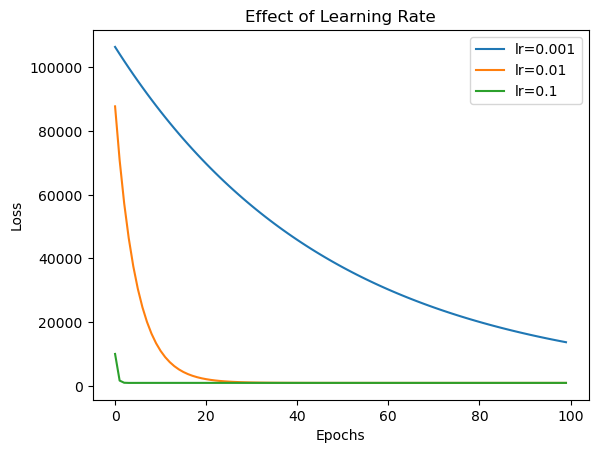

In [32]:
plt.figure()

for lr in learning_rates:
    theta, losses = gradient_descent(X_train, y_train, lr, 100, 16)
    plt.plot(losses, label=f"lr={lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()

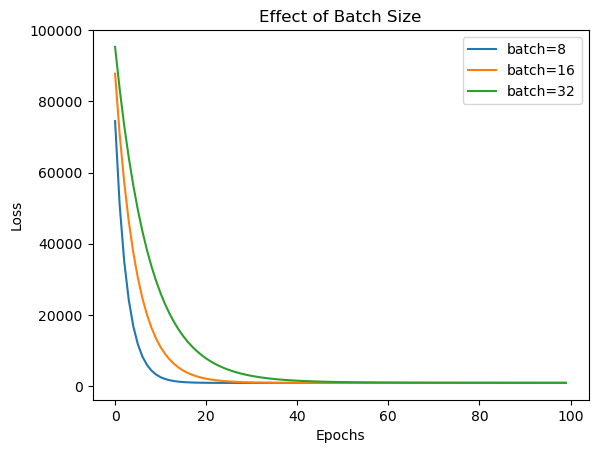

In [33]:
plt.figure()

for batch in batch_sizes:
    theta, losses = gradient_descent(X_train, y_train, 0.01, 100, batch)
    plt.plot(losses, label=f"batch={batch}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Effect of Batch Size")
plt.legend()
plt.show()

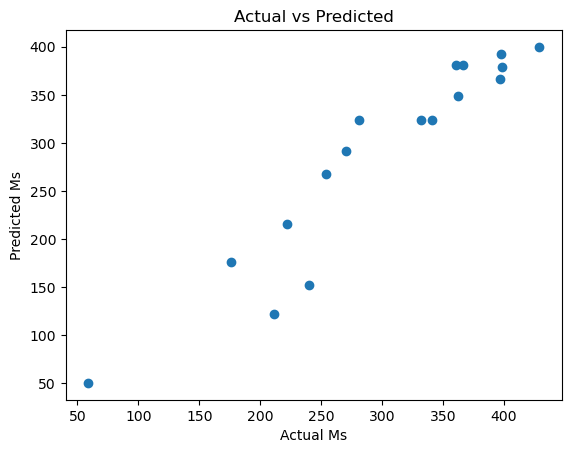

In [34]:
# Train best model again
theta, _ = gradient_descent(X_train, y_train, 0.01, 100, 16)

y_pred = X_test @ theta

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ms")
plt.ylabel("Predicted Ms")
plt.title("Actual vs Predicted")
plt.show()

In [35]:
print(results_df.sort_values(by="R2", ascending=False))

    learning_rate  batch_size  epochs        R2           MSE
12          0.100           8      50  0.869246   1185.927269
13          0.100           8     100  0.869246   1185.927269
15          0.100          16     100  0.868281   1194.682152
14          0.100          16      50  0.868281   1194.682152
16          0.100          32      50  0.865786   1217.310102
17          0.100          32     100  0.865786   1217.310479
9           0.010          16     100  0.860629   1264.088594
7           0.010           8     100  0.860389   1266.260532
6           0.010           8      50  0.859220   1276.865343
11          0.010          32     100  0.853044   1332.878245
8           0.010          16      50  0.846921   1388.414928
10          0.010          32      50  0.772843   2060.298565
1           0.001           8     100  0.467877   4826.312091
3           0.001          16     100 -0.661882  15073.143116
0           0.001           8      50 -1.013487  18262.168529
5       